In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/womens-ecommerce-clothing-reviews


In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import sklearn.metrics as mt

In [3]:
df=pd.read_csv(path + "/Womens Clothing E-Commerce Reviews.csv")
df


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [4]:
df.describe()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [6]:
df=df[['Review Text','Rating','Class Name','Age']]

In [7]:
# prompt: add each word counts to df

from collections import Counter

def count_words(text):
    if isinstance(text, str):  # Check if the input is a string
        words = text.lower().split()
        word_counts = Counter(words)
        return word_counts
    else:
        return Counter()

# Apply the function to the 'Review Text' column and create a new column 'Word Counts'
df['Word Counts'] = df['Review Text'].apply(count_words)

# Display the DataFrame with the new column
df


<ipython-input-7-982e17afc315>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Word Counts'] = df['Review Text'].apply(count_words)


,Review Text,Rating,Class Name,Age,Word Counts
0,Absolutely wonderful - silky and sexy and comf...,4,Intimates,33,"{'absolutely': 1, 'wonderful': 1, '-': 1, 'sil..."
1,Love this dress! it's sooo pretty. i happene...,5,Dresses,34,"{'love': 2, 'this': 1, 'dress!': 1, 'it's': 2,..."
2,I had such high hopes for this dress and reall...,3,Dresses,60,"{'i': 5, 'had': 2, 'such': 1, 'high': 1, 'hope..."
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Pants,50,"{'i': 3, 'love,': 2, 'love': 1, 'this': 1, 'ju..."
4,This shirt is very flattering to all due to th...,5,Blouses,47,"{'this': 2, 'shirt': 1, 'is': 3, 'very': 1, 'f..."
...,...,...,...,...,...
23481,I was very happy to snag this dress at such a ...,5,Dresses,34,"{'i': 1, 'was': 1, 'very': 3, 'happy': 1, 'to'..."
23482,"It reminds me of maternity clothes. soft, stre...",3,Knits,48,"{'it': 1, 'reminds': 1, 'me': 2, 'of': 1, 'mat..."
23483,"This fit well, but the top was very see throug...",3,Dresses,31,"{'this': 2, 'fit': 1, 'well,': 1, 'but': 1, 't..."
23484,I bought this dress for a wedding i have this ...,3,Dresses,28,"{'i': 6, 'bought': 1, 'this': 3, 'dress': 2, '..."


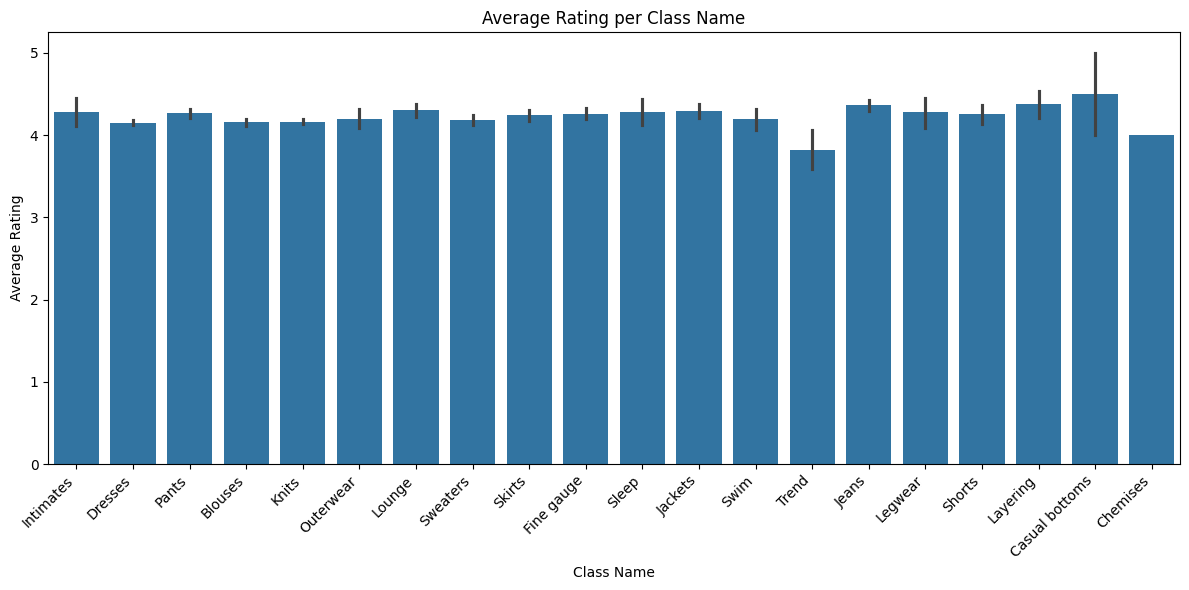

In [8]:
# prompt: bar plot Rating and class name

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame with 'Rating' and 'Class Name' columns
plt.figure(figsize=(12, 6))
sns.barplot(x='Class Name', y='Rating', data=df)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Average Rating per Class Name')
plt.xlabel('Class Name')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


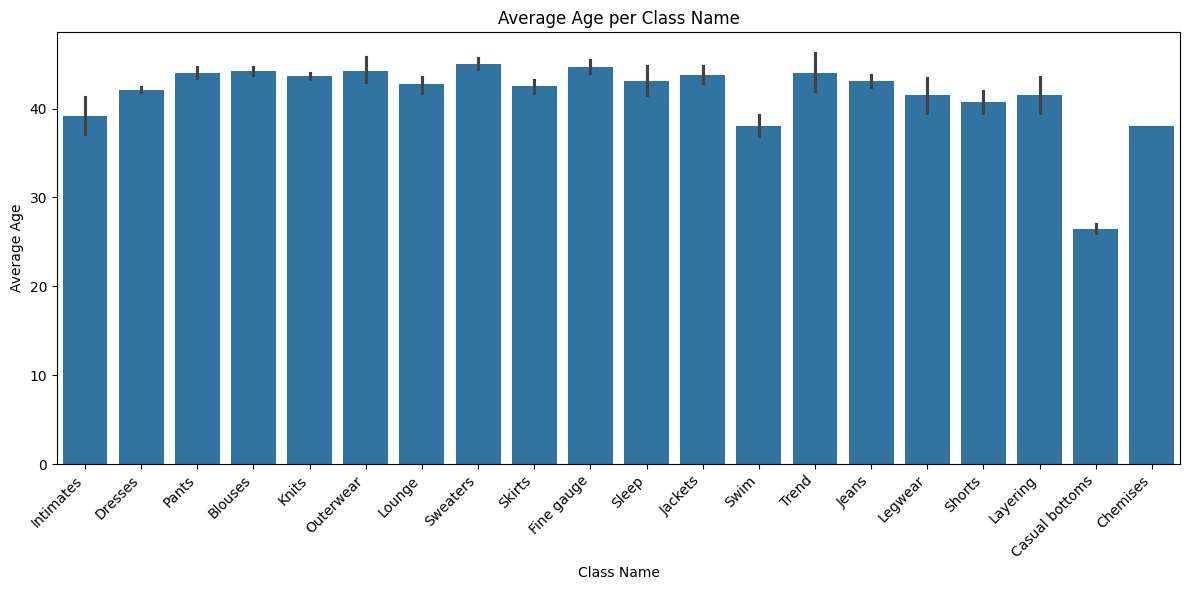

In [9]:
# prompt: bar plot Rating and class name

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame with 'Rating' and 'Class Name' columns
plt.figure(figsize=(12, 6))
sns.barplot(x='Class Name', y='Age', data=df)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Average Age per Class Name')
plt.xlabel('Class Name')
plt.ylabel('Average Age')
plt.tight_layout()
plt.show()


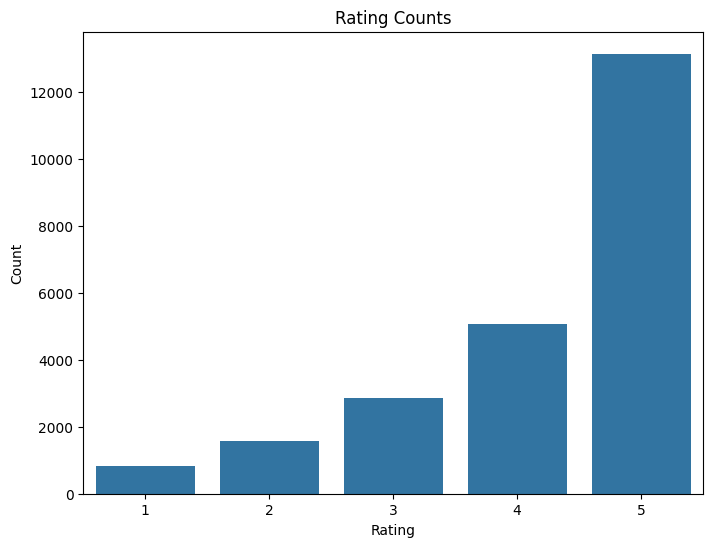

In [10]:
# prompt: rating count plot

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame with 'Rating' column
plt.figure(figsize=(8, 6))
sns.countplot(x='Rating', data=df)
plt.title('Rating Counts')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


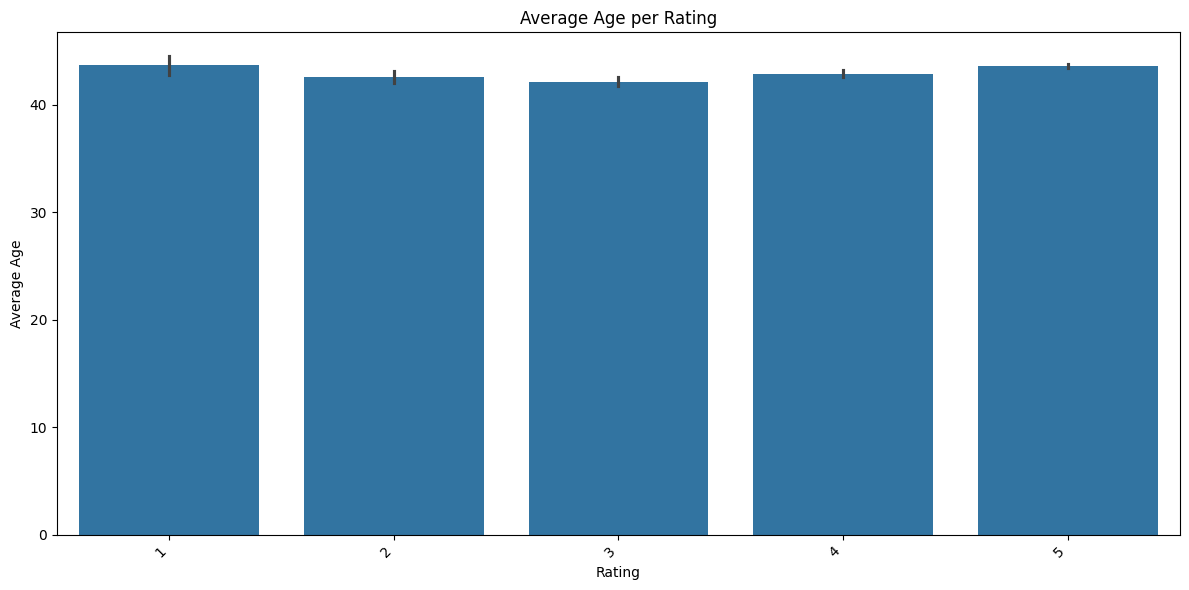

In [11]:
# prompt: bar plot Rating and class name

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame with 'Rating' and 'Class Name' columns
plt.figure(figsize=(12, 6))
sns.barplot(x='Rating', y='Age', data=df)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Average Age per Rating')
plt.xlabel('Rating')
plt.ylabel('Average Age')
plt.tight_layout()
plt.show()


In [12]:
def add_sentiment(rate):
  if rate > 3:
    return 'positive'
  elif rate < 3:
    return 'negative'
  else:
    return 'neutral'

df['Sentiment'] = df['Rating'].apply(add_sentiment)
df

<ipython-input-12-7e5b75e1cec7>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sentiment'] = df['Rating'].apply(add_sentiment)


,Review Text,Rating,Class Name,Age,Word Counts,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,Intimates,33,"{'absolutely': 1, 'wonderful': 1, '-': 1, 'sil...",positive
1,Love this dress! it's sooo pretty. i happene...,5,Dresses,34,"{'love': 2, 'this': 1, 'dress!': 1, 'it's': 2,...",positive
2,I had such high hopes for this dress and reall...,3,Dresses,60,"{'i': 5, 'had': 2, 'such': 1, 'high': 1, 'hope...",neutral
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Pants,50,"{'i': 3, 'love,': 2, 'love': 1, 'this': 1, 'ju...",positive
4,This shirt is very flattering to all due to th...,5,Blouses,47,"{'this': 2, 'shirt': 1, 'is': 3, 'very': 1, 'f...",positive
...,...,...,...,...,...,...
23481,I was very happy to snag this dress at such a ...,5,Dresses,34,"{'i': 1, 'was': 1, 'very': 3, 'happy': 1, 'to'...",positive
23482,"It reminds me of maternity clothes. soft, stre...",3,Knits,48,"{'it': 1, 'reminds': 1, 'me': 2, 'of': 1, 'mat...",neutral
23483,"This fit well, but the top was very see throug...",3,Dresses,31,"{'this': 2, 'fit': 1, 'well,': 1, 'but': 1, 't...",neutral
23484,I bought this dress for a wedding i have this ...,3,Dresses,28,"{'i': 6, 'bought': 1, 'this': 3, 'dress': 2, '...",neutral


In [13]:
df=df[df['Sentiment']!='neutral']
df

,Review Text,Rating,Class Name,Age,Word Counts,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,Intimates,33,"{'absolutely': 1, 'wonderful': 1, '-': 1, 'sil...",positive
1,Love this dress! it's sooo pretty. i happene...,5,Dresses,34,"{'love': 2, 'this': 1, 'dress!': 1, 'it's': 2,...",positive
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Pants,50,"{'i': 3, 'love,': 2, 'love': 1, 'this': 1, 'ju...",positive
4,This shirt is very flattering to all due to th...,5,Blouses,47,"{'this': 2, 'shirt': 1, 'is': 3, 'very': 1, 'f...",positive
5,"I love tracy reese dresses, but this one is no...",2,Dresses,49,"{'i': 4, 'love': 2, 'tracy': 1, 'reese': 1, 'd...",negative
...,...,...,...,...,...,...
23478,I was surprised at the positive reviews for th...,1,Dresses,32,"{'i': 2, 'was': 1, 'surprised': 1, 'at': 1, 't...",negative
23479,So i wasn't sure about ordering this skirt bec...,5,Skirts,42,"{'so': 3, 'i': 8, 'wasn't': 1, 'sure': 1, 'abo...",positive
23480,NaN,5,Knits,35,{},positive
23481,I was very happy to snag this dress at such a ...,5,Dresses,34,"{'i': 1, 'was': 1, 'very': 3, 'happy': 1, 'to'...",positive


In [14]:
df=df.dropna()

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
vectorizer = CountVectorizer()

# split data
train_data,test_data = train_test_split(df,train_size=0.8,random_state=0)
# select the columns and
# prepare data for the models
X_train = vectorizer.fit_transform(train_data['Review Text'])
y_train = train_data['Sentiment']
X_test = vectorizer.transform(test_data['Review Text'])
y_test = test_data['Sentiment']


In [16]:
import datetime as dt
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

start=dt.datetime.now()
lr = LogisticRegression()
lr.fit(X_train,y_train)
print('Elapsed time: ',str(dt.datetime.now()-start))

Elapsed time:  0:00:03.262599


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
start=dt.datetime.now()
nb = MultinomialNB()
nb.fit(X_train,y_train)
print('Elapsed time: ',str(dt.datetime.now()-start))

Elapsed time:  0:00:00.112287


In [18]:
start=dt.datetime.now()
svm = SVC()
svm.fit(X_train,y_train)
print('Elapsed time: ',str(dt.datetime.now()-start))

Elapsed time:  0:00:44.019393


In [19]:
start=dt.datetime.now()
nn = MLPClassifier()
nn.fit(X_train,y_train)
print('Elapsed time: ',str(dt.datetime.now()-start))

Elapsed time:  0:01:20.322317


In [20]:
# prompt: evaluate models

# Predict on the test set
lr_pred = lr.predict(X_test)
nb_pred = nb.predict(X_test)
svm_pred = svm.predict(X_test)
nn_pred = nn.predict(X_test)

# Evaluate the models
print("Logistic Regression:")
print(mt.classification_report(y_test, lr_pred))
print("Naive Bayes:")
print(mt.classification_report(y_test, nb_pred))
print("SVM:")
print(mt.classification_report(y_test, svm_pred))
print("Neural Network:")
print(mt.classification_report(y_test, nn_pred))

# Confusion matrices
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nNaive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

print("\nNeural Network Confusion Matrix:")
print(confusion_matrix(y_test, nn_pred))


Logistic Regression:
              precision    recall  f1-score   support

    negative       0.72      0.64      0.68       450
    positive       0.95      0.97      0.96      3511

    accuracy                           0.93      3961
   macro avg       0.84      0.80      0.82      3961
weighted avg       0.93      0.93      0.93      3961

Naive Bayes:
              precision    recall  f1-score   support

    negative       0.73      0.64      0.68       450
    positive       0.95      0.97      0.96      3511

    accuracy                           0.93      3961
   macro avg       0.84      0.81      0.82      3961
weighted avg       0.93      0.93      0.93      3961

SVM:
              precision    recall  f1-score   support

    negative       0.81      0.47      0.59       450
    positive       0.94      0.99      0.96      3511

    accuracy                           0.93      3961
   macro avg       0.87      0.73      0.78      3961
weighted avg       0.92      0.93  

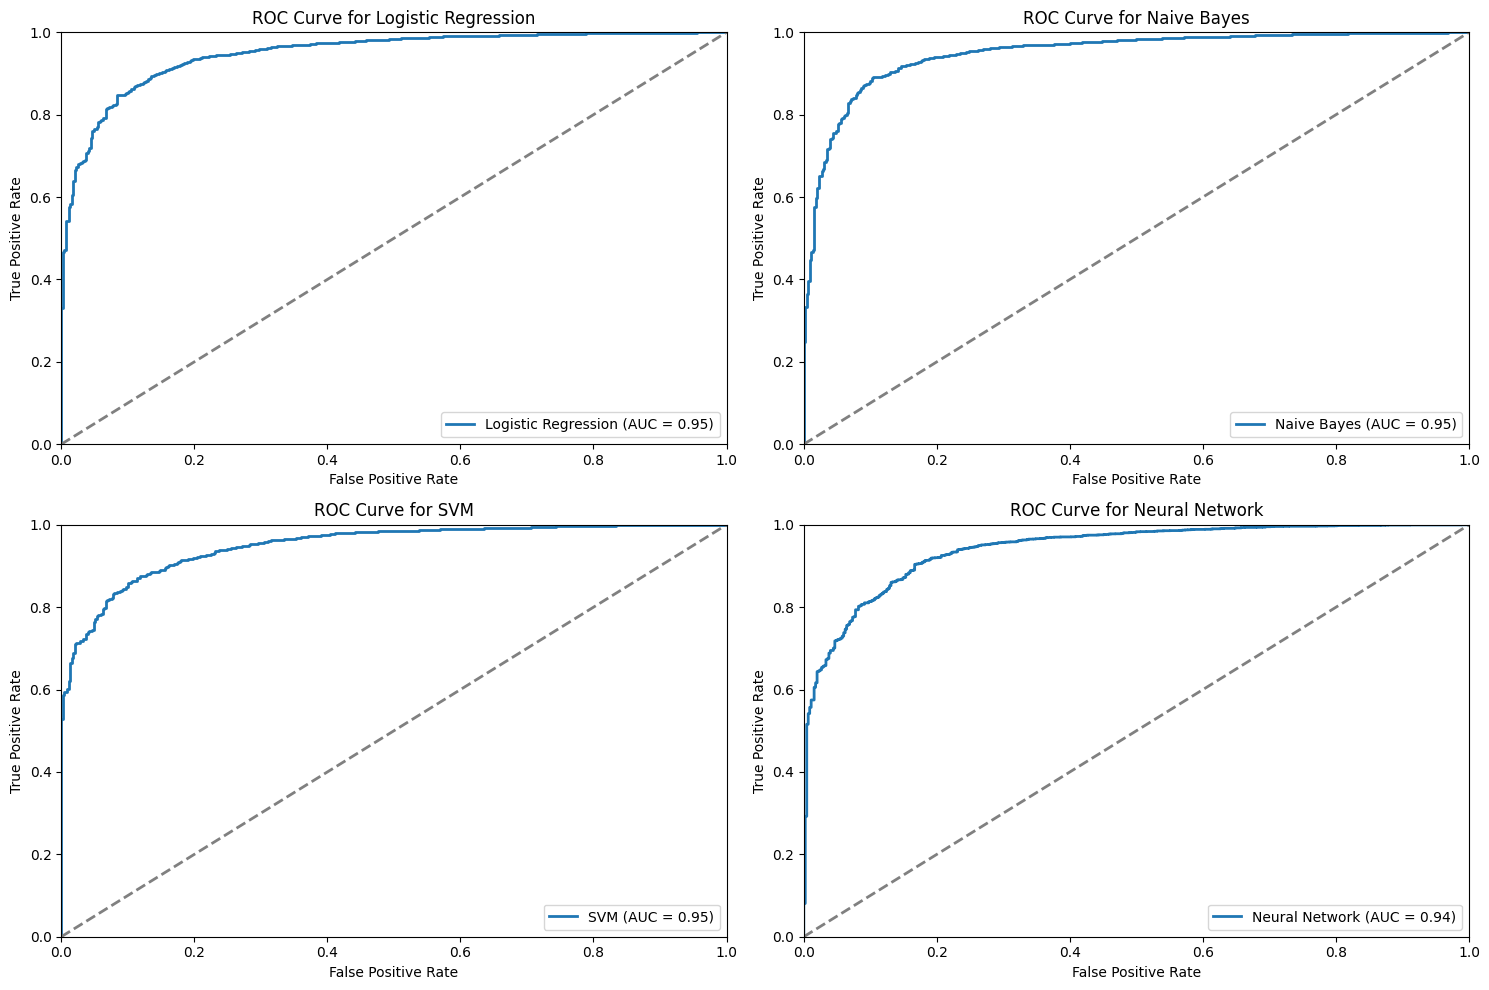

In [21]:
# prompt: ROC Curves and AUC in subplots

# Assuming lr, nb, svm, and nn are your trained models
# and X_test, y_test are your test data

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = [lr, nb, svm, nn]
model_names = ['Logistic Regression', 'Naive Bayes', 'SVM', 'Neural Network']

plt.figure(figsize=(15, 10))

for i, model in enumerate(models):
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probability of positive class
    else:
        # For models without predict_proba (like SVM), use decision_function
        # or another appropriate method to get scores
        if hasattr(model, "decision_function"):
          y_pred_prob = model.decision_function(X_test)
        else:
          # Handle cases where neither predict_proba nor decision_function exists
          print(f"Warning: {model_names[i]} does not have predict_proba or decision_function. Skipping ROC curve.")
          continue

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, pos_label='positive')
    roc_auc = auc(fpr, tpr)

    plt.subplot(2, 2, i + 1)
    plt.plot(fpr, tpr, lw=2, label=f'{model_names[i]} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_names[i]}')
    plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


In [22]:
X = vectorizer.transform(df['Review Text'])

In [28]:
df['Logistic Regression'] = lr.predict(X)
df['Naive Bayes'] = nb.predict(X)
df['SVM'] = svm.predict(X)
df['Neural Network'] = nn.predict(X)

<ipython-input-28-8a1f3794ea7d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Logistic Regression'] = lr.predict(X)
<ipython-input-28-8a1f3794ea7d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Naive Bayes'] = nb.predict(X)
<ipython-input-28-8a1f3794ea7d>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gu

In [29]:
df

,Review Text,Rating,Class Name,Age,Word Counts,Sentiment,Logistic Regression,Naive Bayes,SVM,Neural Network
0,Absolutely wonderful - silky and sexy and comf...,4,Intimates,33,"{'absolutely': 1, 'wonderful': 1, '-': 1, 'sil...",positive,positive,positive,positive,positive
1,Love this dress! it's sooo pretty. i happene...,5,Dresses,34,"{'love': 2, 'this': 1, 'dress!': 1, 'it's': 2,...",positive,positive,positive,positive,positive
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Pants,50,"{'i': 3, 'love,': 2, 'love': 1, 'this': 1, 'ju...",positive,positive,positive,positive,positive
4,This shirt is very flattering to all due to th...,5,Blouses,47,"{'this': 2, 'shirt': 1, 'is': 3, 'very': 1, 'f...",positive,positive,positive,positive,positive
5,"I love tracy reese dresses, but this one is no...",2,Dresses,49,"{'i': 4, 'love': 2, 'tracy': 1, 'reese': 1, 'd...",negative,negative,negative,negative,negative
...,...,...,...,...,...,...,...,...,...,...
23477,I'm so impressed with the beautiful color comb...,4,Dresses,39,"{'i'm': 1, 'so': 2, 'impressed': 1, 'with': 2,...",positive,positive,positive,positive,positive
23478,I was surprised at the positive reviews for th...,1,Dresses,32,"{'i': 2, 'was': 1, 'surprised': 1, 'at': 1, 't...",negative,negative,negative,negative,negative
23479,So i wasn't sure about ordering this skirt bec...,5,Skirts,42,"{'so': 3, 'i': 8, 'wasn't': 1, 'sure': 1, 'abo...",positive,positive,positive,positive,positive
23481,I was very happy to snag this dress at such a ...,5,Dresses,34,"{'i': 1, 'was': 1, 'very': 3, 'happy': 1, 'to'...",positive,positive,positive,positive,positive
